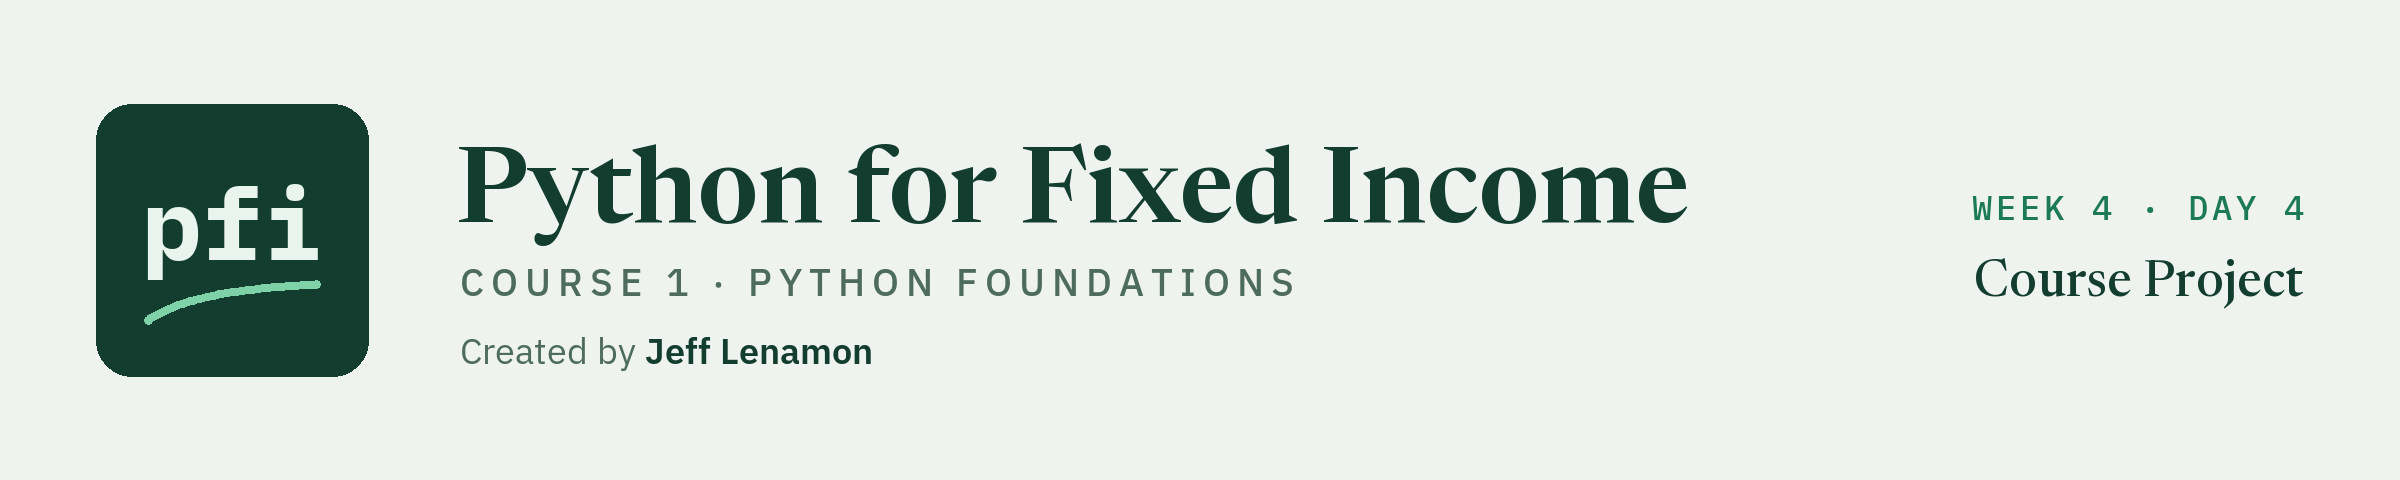

# Course Project

Week 4, days 4 and 5. A new month-end extract is checked, cleaned, summarized, charted, and compared with its benchmark, and the result is written up for the portfolio manager. You write the code.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day4/course1_project.ipynb)

## The brief

### The scenario

It is month end. You are the analyst on the credit desk, and the operations team has sent the holdings extract for 2026-10-30 with a cover note. The portfolio manager wants a written picture of the book before the month-end meeting: what is in it, where it is concentrated, whether the file can be trusted, and how the book differs from its benchmark.

This is the same desk and the same kind of extract as week 3, one month later. It is a new file. What was wrong with the September extract tells you nothing about what is wrong with this one. Run the routine, do not remember it.

Everything in the files is invented: the issuers, the tickers, the CUSIPs, the prices, and the positions. No name here refers to a real company.

### The cover note

```
To: Credit desk
From: Operations
Subject: Month-end holdings extract, as of 2026-10-30

The month-end extract is attached as project_holdings.csv.

Control totals for the book:
  Number of bonds:      206
  Total face:           507,250,000 dollars
  Total market value:   509,928,477.50 dollars

Market value is face times clean price plus accrued interest, divided by 100.
All positions are priced as of 2026-10-30.
Please tell us if the extract does not agree with these totals.
```

The note is also in the course repo as `data/project_cover_note.txt`.

### What to hand in

This notebook, completed: every code cell filled in and run from top to bottom, every decision written down, and the written conclusion of section 9.

### How long

Two days.

| Day | Sections |
| --- | --- |
| Week 4, day 4 | 1 structure, 2 data types, 3 sanity checks and data quality, 4 missing values, 5 summary statistics |
| Week 4, day 5 | 6 one column at a time, 7 two or more columns, 8 the desk's questions, 9 the conclusion |

Day 4 ends with a table you trust. Day 5 describes it.

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.2 makes the working copy, `book`, and every fix is made to `book`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and what evidence in the files supports it.
3. **Print the headline numbers before and after every fix.** The setup cell gives you `headline()` for that.
4. **Describe, never recommend.** Every sentence you write says what the data shows. Nothing recommends, ranks, or forecasts a bond, an issuer, or a sector.
5. **Charts are finished charts.** A title, a label on each axis, and the unit.
6. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

* Every earlier notebook of the course, and your own notes.
* The documentation of pandas, matplotlib, and seaborn.
* An AI assistant, used the way the course taught: read the code it gives you, predict what it will print, run it, and check the result against a number you worked out yourself or against a control total. An answer you cannot check is not finished. Nothing from an employer goes into an AI tool or into Colab. The course data is synthetic for that reason.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_3_2`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`. A check tests the number. It does not test your reasoning, and charts and written answers have no check: each of those questions says what a good answer includes.

Your cleaning decisions change the numbers that follow. Where a check depends on a decision, the question states the decision the check expects. A different decision can be defensible. If you make one, say so in a markdown cell and expect the check to disagree.

After section 4 there is a checkpoint cell that tests your cleaned table against the cover note. Do not go on to day 5 until it passes.

Worked answers are in `course1_project_solutions.ipynb` in this folder. Open it after you have written your own conclusion.

## The data

Three files. Units: **`coupon` and `yield_pct` are in percent, `oas` is in basis points, `duration` is in years, `price` and `accrued` are per 100 of face, and `par_held`, `amount_outstanding`, and `market_value` are in dollars.**

**`project_holdings.csv`**: the extract. One row should be one bond the desk holds.

| Column | Meaning | Units |
| --- | --- | --- |
| `as_of_date` | the date the book is valued | year-month-day |
| `cusip` | the bond's identifier, nine characters | text |
| `ticker` | the issuer's ticker, four capital letters | text |
| `issuer` | the issuer's name | text |
| `sector` | one of ten sectors | text |
| `rating` | the bond's rating, from AAA to CCC | text |
| `coupon` | annual coupon rate | percent |
| `maturity` | the date the bond repays | year-month-day |
| `price` | clean price | per 100 of face |
| `price_date` | the date of the price | year-month-day |
| `accrued` | accrued interest | per 100 of face |
| `yield_pct` | yield to maturity | percent |
| `oas` | option-adjusted spread, a whole number | basis points |
| `duration` | modified duration | years |
| `spread_duration` | spread duration, equal to the duration for these bonds | years |
| `dts` | duration times spread: spread duration times OAS, to one decimal place | years times basis points |
| `amount_outstanding` | face of the whole issue | dollars |
| `par_held` | face the desk holds | dollars |
| `market_value` | face held times (price plus accrued), divided by 100 | dollars |

**`ratings.csv`**: the rating scale, 18 rows. `rating`, `score` (1 for AAA up to 18 for CCC, so a higher score is a lower rating), `bucket` (the rating without its plus or minus), and `grade` (Investment Grade or High Yield).

**`benchmark.csv`**: the benchmark the book is measured against, 821 bonds. It has the same columns as the extract with two differences: there is no `par_held`, and there is a `weight_pct` column, the weight of each bond in the benchmark in percent. Its `market_value` is that of the whole issue. **The benchmark file is the September file, as of 2026-09-30.** The desk has not been sent an October one. In this project the book is compared with it by sector weights and by rating bucket weights only, and the conclusion says that the two files are a month apart.

## Setup

Run this cell first. It is complete: do not change it. It imports the libraries, loads the three files, stores the control totals from the cover note, and defines two helpers: `headline()`, which prints the headline numbers of a table, and `check()`, which marks your answers. It prints the three shapes: (209, 19), (18, 4), and (821, 19).

In [1]:
# os is used to find the data folder
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/project_holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# raw is the extract exactly as it arrived. Nothing you write should change it.
raw = pd.read_csv(data_folder + 'project_holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

# the control totals from the cover note
expected_bonds = 206
expected_face = 507_250_000
expected_value = 509_928_477.50


def headline(label, table):
    # the headline numbers, to print before and after every fix
    print(label)
    print('   rows:', len(table))
    print('   face:', table['par_held'].sum(), 'dollars')
    print('   market value:', table['market_value'].sum(), 'dollars')
    print('   mean OAS:', round(table['oas'].mean(), 2), 'basis points')


def check(label, answer, expected):
    """Compare an answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


print('raw:', raw.shape, ' ratings:', ratings.shape, ' benchmark:', benchmark.shape)

raw: (209, 19)  ratings: (18, 4)  benchmark: (821, 19)


## 1 The structure of the data

### 1.1 Rows and columns

Q. How many rows and columns does the extract have? Store the shape, a pair of numbers (rows, columns), in **answer_1_1**, and show the first five rows. In a sentence, say what one row of this file is.

In [2]:
# your code here
answer_1_1 = ...

In [3]:
check('Question 1.1', answer_1_1, (209, 19))

Question 1.1: not attempted yet


### 1.2 Identifiers and dates

Q. How many different as-of dates, CUSIPs, tickers, and issuer names are in the file? Store the number of different CUSIPs in **answer_1_2**.

In [4]:
# your code here
answer_1_2 = ...

In [5]:
check('Question 1.2', answer_1_2, 206)

Question 1.2: not attempted yet


## 2 Data types

### 2.1 The type of each column

Q. What type did pandas give each column? Count the columns held as numbers and store the count in **answer_2_1**. In a sentence, say which columns hold dates and what type they have.

In [6]:
# your code here
answer_2_1 = ...

In [7]:
check('Question 2.1', answer_2_1, 11)

Question 2.1: not attempted yet


### 2.2 A working copy with real dates

Q. Make a working copy of `raw` called `book`, and convert its three date columns to dates. Count the dates that could not be read, over the three columns, and store the count in **answer_2_2**. Print the earliest and the latest value of each date column.

From here on every fix is made to `book`, and `raw` stays as it arrived.

In [8]:
# your code here
book = ...
answer_2_2 = ...

In [9]:
check('Question 2.2', answer_2_2, 0)

Question 2.2: not attempted yet


## 3 Sanity checks and data quality

A sanity check asks a question whose answer is known before looking. This section is the longest of day 4. Work through it in order: the cover note first, then the rows, the identifiers, the categories, the values, the dates, and whether the file agrees with itself. It ends with the cover note again.

### 3.1 The file against the cover note

Q. Print the headline numbers of the extract as received. Then print the difference between the file and the cover note, file less cover note, for the number of rows, the total face, and the total market value. Store the difference in rows in **answer_3_1**. In a sentence, say what the three differences suggest.

In [10]:
# your code here
answer_3_1 = ...

In [11]:
check('Question 3.1', answer_3_1, 3)

Question 3.1: not attempted yet


### 3.2 Repeated rows

Q. How many rows of `book` are an exact copy of an earlier row? Store the count in **answer_3_2**. Show each copy next to the row it repeats, with the face and market value the copies carry.

**Expected decision:** remove exact duplicate rows, keeping the first of each. Print the headline numbers before and after, and the differences from the cover note after.

In [12]:
# your code here
answer_3_2 = ...

In [13]:
check('Question 3.2', answer_3_2, 3)

Question 3.2: not attempted yet


### 3.3 Identifiers

Q. Check the identifiers of `book`. Is every CUSIP nine characters long, and is each one there once? Is every CUSIP also in `benchmark.csv`? Is every ticker free of stray spaces and lower case? Store the number of CUSIPs that are **not** found in the benchmark in **answer_3_3**.

In [14]:
# your code here
answer_3_3 = ...

In [15]:
check('Question 3.3', answer_3_3, 0)

Question 3.3: not attempted yet


### 3.4 Categories

Q. Are the category columns consistent? List every value of `sector` with its count, and test whether every `rating` is on the rating scale. Store the number of different values in the `sector` column of `book`, before any fix, in **answer_3_4**.

**Expected decision:** sector names that differ only in upper and lower case, or in spaces at the ends, are one sector. Tidy them. Print the number of different sectors before and after, and show what the fix does to the market value of one sector.

In [16]:
# your code here
answer_3_4 = ...

In [17]:
check('Question 3.4', answer_3_4, 19)

Question 3.4: not attempted yet


### 3.5 Values that cannot be right

Q. Does any column of `book` hold a value that cannot be right for a bond the desk holds? Test at least these six rules and print the number of rows that break each:

* a price of zero or less
* a coupon of zero or less
* a duration of zero or less
* a face held of zero or less
* a face held above the amount outstanding
* a maturity on or before the as-of date

Store the total number of rule breaks, added over the six rules, in **answer_3_5**, and show the rows that break a rule. Do not fix anything yet.

In [18]:
# your code here
answer_3_5 = ...

In [19]:
check('Question 3.5', answer_3_5, 3)

Question 3.5: not attempted yet


### 3.6 Price dates

Q. Is every position priced at month end? Count the rows of `book` whose `price_date` is not the `as_of_date`, and store the count in **answer_3_6**.

In [20]:
# your code here
answer_3_6 = ...

In [21]:
check('Question 3.6', answer_3_6, 0)

Question 3.6: not attempted yet


### 3.7 Does the file agree with itself?

Q. The cover note says market value is face times clean price plus accrued interest, divided by 100. Work that out for every row of `book` and compare it with the `market_value` column. Store the number of rows where the two differ by more than 1 dollar in **answer_3_7**, and show those rows. Do not fix anything yet.

In [22]:
# your code here
answer_3_7 = ...

In [23]:
check('Question 3.7', answer_3_7, 5)

Question 3.7: not attempted yet


### 3.8 Decisions

Q. Read the rows found in 3.5 and 3.7. For each one, decide which column is wrong, and say what evidence in the files supports the decision. Then make the fixes, printing the headline numbers before and after each one.

**Expected decisions:**

* a face held with the wrong sign becomes the positive amount;
* a price in the wrong units is put back into price per 100 of face, rounded to 3 decimal places;
* a maturity that cannot be right is replaced with the maturity of the same CUSIP in `benchmark.csv`.

When the fixes are made, run the tests of 3.5 and 3.7 again. Store the number of rows that still fail any of them in **answer_3_8**.

In [24]:
# your code here
answer_3_8 = ...

In [25]:
check('Question 3.8', answer_3_8, 0)

Question 3.8: not attempted yet


### 3.9 The cover note again

Q. Does the corrected table agree with the cover note? Print the three differences, table less cover note, and store the difference in market value, rounded to 2 decimal places, in **answer_3_9**.

In [26]:
# your code here
answer_3_9 = ...

In [27]:
check('Question 3.9', answer_3_9, 0.0)

Question 3.9: not attempted yet


## 4 Missing values

### 4.1 How many, and where

Q. How many values are missing in each column of `book`? Print the columns that have at least one. Store the total number of missing cells in **answer_4_1**.

In [28]:
# your code here
answer_4_1 = ...

In [29]:
check('Question 4.1', answer_4_1, 4)

Question 4.1: not attempted yet


### 4.2 Which bonds

Q. Show the rows with a missing value. What share of the book's market value are they? Store the share, in percent rounded to 2 decimal places, in **answer_4_2**. In a sentence, say whether the gaps share a sector, an issuer, or a rating.

In [30]:
# your code here
answer_4_2 = ...

In [31]:
check('Question 4.2', answer_4_2, 3.33)

Question 4.2: not attempted yet


### 4.3 The decision

Q. What does each choice do to the numbers: leaving the gaps, dropping the rows, or filling them? Try the first two without changing `book`, and print the row count, the market value, and the mean OAS each gives.

**Expected decision:** the data dictionary says `dts` is spread duration times OAS. So a missing OAS can be worked out from two columns of its own row: `dts` divided by `spread_duration`, rounded to a whole basis point. Before you use that rule, test it on the rows where the OAS is present. Then fill the gaps, print the headline numbers before and after, and store the mean OAS of `book`, rounded to 2 decimal places, in **answer_4_3**.

In [32]:
# your code here
answer_4_3 = ...

In [33]:
check('Question 4.3', answer_4_3, 190.09)

Question 4.3: not attempted yet


### Checkpoint: the cleaned table

Run this cell when sections 1 to 4 are done. It tests `book` against the cover note and against the expected decisions. Every line should print `correct` before you go on to day 5.

In [34]:
if book is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(book), 206)
    check('Checkpoint face', book['par_held'].sum(), 507250000)
    check('Checkpoint market value', round(book['market_value'].sum(), 2), 509928477.5)
    check('Checkpoint different sectors', book['sector'].nunique(), 10)
    check('Checkpoint missing cells', book.isna().sum().sum(), 0)
    check('Checkpoint mean OAS', round(book['oas'].mean(), 2), 190.09)
    check('Checkpoint mean price', round(book['price'].mean(), 3), 98.806)
    check('Checkpoint raw is unchanged', raw.shape, (209, 19))

Checkpoint: not attempted yet


## 5 Summary statistics

### 5.1 The rating scale

Q. Add the `score`, `bucket`, and `grade` of each rating to `book` from the rating scale. Print the number of rows before and after, and the number of bonds in each grade. Store the number of High Yield bonds in **answer_5_1**.

In [35]:
# your code here
answer_5_1 = ...

In [36]:
check('Question 5.1', answer_5_1, 76)

Question 5.1: not attempted yet


### 5.2 Summary statistics

Q. Produce the summary statistics of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `market_value`: count, mean, standard deviation, minimum, quartiles, and maximum, rounded to 2 decimal places. Read each column from its minimum to its maximum and say whether a bond could have those values. Store the median OAS in **answer_5_2**.

In [37]:
# your code here
answer_5_2 = ...

In [38]:
check('Question 5.2', answer_5_2, 138.5)

Question 5.2: not attempted yet


### 5.3 Mean, median, and skew

Q. For `coupon`, `price`, `yield_pct`, `oas`, `duration`, `dts`, and `market_value`, show the mean, the median, and the skew in one table, rounded to 2 decimal places. Which column has the longest tail on the right, and which has its tail on the left? Store the skew of the OAS, rounded to 2 decimal places, in **answer_5_3**.

In [39]:
# your code here
answer_5_3 = ...

In [40]:
check('Question 5.3', answer_5_3, 3.47)

Question 5.3: not attempted yet


### 5.4 Counts by category

Q. How many bonds are in each sector, in each rating bucket, and in each grade? List the buckets in credit order, from AAA to CCC. Store the name of the bucket with the most bonds in **answer_5_4**.

In [41]:
# your code here
answer_5_4 = ...

In [42]:
check('Question 5.4', answer_5_4, 'BBB')

Question 5.4: not attempted yet


## 6 One column at a time

Day 5 starts here. The table is `book` as it stood at the checkpoint, with the rating scale joined in question 5.1.

### 6.1 The distribution of the OAS

Q. Draw a histogram of the OAS of the bonds, with a vertical line at the mean and another at the median. How many bonds have an OAS above the mean? Store the count in **answer_6_1**.

A good chart here has a title, the unit on the x axis, a label on the y axis, and a legend that says which line is which.

In [43]:
# your code here
answer_6_1 = ...

In [44]:
check('Question 6.1', answer_6_1, 61)

Question 6.1: not attempted yet


### 6.2 The IQR rule

Q. Apply the IQR rule to the OAS. Print the two quartiles, the IQR, and the two limits, and draw a box plot of the column. Store the upper limit in **answer_6_2a** and the number of bonds above it in **answer_6_2b**.

In [45]:
# your code here
answer_6_2a = ...
answer_6_2b = ...

In [46]:
check('Question 6.2 upper limit', answer_6_2a, 399.625)
check('Question 6.2 bonds flagged', answer_6_2b, 18)

Question 6.2 upper limit: not attempted yet
Question 6.2 bonds flagged: not attempted yet


### 6.3 Errors or real bonds?

Q. Show the flagged bonds, widest first, with their rating, coupon, price, yield, and OAS. Are they errors or real bonds? Give the evidence from the other columns.

**Expected decision:** a row is corrected if it is an error and the right value is known, flagged if it is an error and the right value is not known, and kept if it is real. No row is deleted for being far away.

Store the flagged bonds' share of the book's market value, in percent rounded to 2 decimal places, in **answer_6_3**.

In [47]:
# your code here
answer_6_3 = ...

In [48]:
check('Question 6.3', answer_6_3, 7.62)

Question 6.3: not attempted yet


### 6.4 The distribution of the price

Q. Draw a histogram of the clean price. How many bonds are priced below 100? Store the count in **answer_6_4**. Show the bond with the lowest price and the bond with the highest, and say whether either is an error.

In [49]:
# your code here
answer_6_4 = ...

In [50]:
check('Question 6.4', answer_6_4, 114)

Question 6.4: not attempted yet


### 6.5 The size of the positions

Q. Draw a histogram of the market value of the positions, in millions of dollars. Which is the largest position, and what share of the book is it? Store that share, in percent rounded to 2 decimal places, in **answer_6_5**. Does the IQR rule flag any position as large?

In [51]:
# your code here
answer_6_5 = ...

In [52]:
check('Question 6.5', answer_6_5, 1.07)

Question 6.5: not attempted yet


## 7 Two or more columns

### 7.1 Correlations

Q. Produce the correlation table of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `score`, rounded to 2 decimal places, and draw it as a heatmap with the number in each cell. Store the correlation of OAS and score, rounded to 2 decimal places, in **answer_7_1**.

A good answer names the strongest pair, a pair near zero, and says what the sign of the OAS and score figure means given how the score is built.

In [53]:
# your code here
answer_7_1 = ...

In [54]:
check('Question 7.1', answer_7_1, 0.76)

Question 7.1: not attempted yet


### 7.2 OAS against duration, by grade

Q. Draw a scatter plot of OAS against duration, with the two grades in different colours. Then work out the correlation of duration and yield for the whole book and within each grade. Store the Investment Grade figure, rounded to 2 decimal places, in **answer_7_2**.

A good answer says what the whole-book figure hides.

In [55]:
# your code here
answer_7_2 = ...

In [56]:
check('Question 7.2', answer_7_2, 0.61)

Question 7.2: not attempted yet


### 7.3 OAS by rating bucket

Q. Show the number of bonds and the median, lowest, and highest OAS of each rating bucket, in credit order, and draw the median OAS by bucket as a bar chart. Store the median OAS of the BBB bucket in **answer_7_3**.

In [57]:
# your code here
answer_7_3 = ...

In [58]:
check('Question 7.3', answer_7_3, 132.5)

Question 7.3: not attempted yet


### 7.4 OAS by grade

Q. Compare the OAS of the two grades with a box plot, one box for each grade. Print the number of bonds and the median of each. Store the High Yield median less the Investment Grade median in **answer_7_4**.

In [59]:
# your code here
answer_7_4 = ...

In [60]:
check('Question 7.4', answer_7_4, 170.0)

Question 7.4: not attempted yet


### 7.5 Sector by grade

Q. Build a pivot table of market value, in millions of dollars, with the sectors down the side and the two grades across the top, and draw it as a heatmap with the number in each cell. Check that the cells add up to the market value of the book. Store the name of the sector with the most High Yield market value in **answer_7_5**.

In [61]:
# your code here
answer_7_5 = ...

In [62]:
check('Question 7.5', answer_7_5, 'Materials')

Question 7.5: not attempted yet


## 8 The desk's questions

These are the questions the portfolio manager will ask. Each answer is a table or a figure with its unit. Weights are percent of the book's market value unless the question says otherwise.

### 8.1 Value and weight by sector

Q. Add a `weight_pct` column to `book`: each bond's market value as a percent of the book's. Then show, for each sector, the number of bonds, the market value, and the weight, largest weight first. Check that the weights add up to 100. Store the weight of the largest sector, rounded to 2 decimal places, in **answer_8_1**.

In [63]:
# your code here
answer_8_1 = ...

In [64]:
check('Question 8.1', answer_8_1, 14.34)

Question 8.1: not attempted yet


### 8.2 Value and weight by rating bucket and grade

Q. Show the same three figures for each rating bucket, in credit order, and the weight of each grade. Store the High Yield weight, rounded to 2 decimal places, in **answer_8_2**.

In [65]:
# your code here
answer_8_2 = ...

In [66]:
check('Question 8.2', answer_8_2, 34.96)

Question 8.2: not attempted yet


### 8.3 The ten largest issuers

Q. How many issuers are in the book? Which ten have the most market value, and what share of the book are the ten together? Store that share, in percent rounded to 2 decimal places, in **answer_8_3**.

In [67]:
# your code here
answer_8_3 = ...

In [68]:
check('Question 8.3', answer_8_3, 21.44)

Question 8.3: not attempted yet


### 8.4 Weighted averages

Q. What are the average coupon, OAS, duration, and rating score of the book, both simple and weighted by market value? Store the weighted average OAS, rounded to 1 decimal place, in **answer_8_4a**, and the weighted average duration, rounded to 2 decimal places, in **answer_8_4b**.

In [69]:
# your code here
answer_8_4a = ...
answer_8_4b = ...

In [70]:
check('Question 8.4 weighted OAS', answer_8_4a, 181.3)
check('Question 8.4 weighted duration', answer_8_4b, 6.08)

Question 8.4 weighted OAS: not attempted yet
Question 8.4 weighted duration: not attempted yet


### 8.5 DTS by sector

Q. A bond's contribution to the DTS of the book is its weight, as a fraction of the book, times its DTS. The contributions of all the bonds add up to the DTS of the book. Add a `dts_contribution` column to `book`. Then show, for each sector, its weight, its contribution, and its share of the book's DTS in percent, largest contribution first. Show the same for the two grades. Store the DTS of the book, rounded to 1 decimal place, in **answer_8_5**.

In [71]:
# your code here
answer_8_5 = ...

In [72]:
check('Question 8.5', answer_8_5, 1022.3)

Question 8.5: not attempted yet


### 8.6 Maturing within three years

Q. How many bonds mature within three years of the as-of date, and what share of the book are they? Count the years as the days from the as-of date to the maturity, divided by 365.25, as in notebook 10. Store the share, in percent rounded to 2 decimal places, in **answer_8_6**.

In [73]:
# your code here
answer_8_6 = ...

In [74]:
check('Question 8.6', answer_8_6, 18.53)

Question 8.6: not attempted yet


### 8.7 The book against its benchmark, by sector

The benchmark file gives each of its 821 bonds a `weight_pct`. Adding those weights within a sector gives the benchmark's sector weight. The difference, **book weight less benchmark weight**, is in percentage points.

A positive difference is called an **overweight** and a negative one an **underweight**. In this project the two words are arithmetic and nothing more: they name the sign of a subtraction. They do not say that a weight is too high or too low, and they are not a view on any sector.

The benchmark file is the September file and the book is October's. Say so wherever the comparison is reported.

Q. Show, for each sector, the book weight, the benchmark weight, and the difference, sorted by the difference. Draw the differences as a horizontal bar chart with a line at zero. Store the name of the sector with the largest positive difference in **answer_8_7a** and that difference, rounded to 2 decimal places, in **answer_8_7b**.

A good chart here says in its title which way the subtraction runs.

In [75]:
# your code here
answer_8_7a = ...
answer_8_7b = ...

In [76]:
check('Question 8.7 sector', answer_8_7a, 'Financials')
check('Question 8.7 difference', answer_8_7b, 2.79)

Question 8.7 sector: not attempted yet
Question 8.7 difference: not attempted yet


### 8.8 The book against its benchmark, by rating bucket

Q. Make the same comparison by rating bucket, in credit order, and by grade. The benchmark needs the rating scale joined to it first. Draw the bucket differences as a bar chart with a line at zero and the buckets in credit order. Store the difference for the BBB bucket, rounded to 2 decimal places, in **answer_8_8**.

In [77]:
# your code here
answer_8_8 = ...

In [78]:
check('Question 8.8', answer_8_8, -2.69)

Question 8.8: not attempted yet


### 8.9 The bonds that carry the most DTS

Q. Which ten bonds contribute the most to the DTS of the book? Show their CUSIP, ticker, rating, OAS, duration, DTS, weight, and contribution. Store the ten bonds' share of the book's DTS, in percent rounded to 1 decimal place, in **answer_8_9**, and print their combined weight beside it.

In [79]:
# your code here
answer_8_9 = ...

In [80]:
check('Question 8.9', answer_8_9, 22.2)

Question 8.9: not attempted yet


## 9 The conclusion

### 9.1 The written picture of the book

Q. Write the page for the portfolio manager, in a markdown cell, in 250 to 350 words. Use this outline:

1. **The book in five numbers.** The five figures a reader needs first, each with its unit.
2. **Concentrations.** Where the market value and the DTS sit: by sector, by grade, by issuer.
3. **Data quality.** Each problem found in the extract, in how many rows, and what was done. Say what was checked and found clean.
4. **Against the benchmark.** The differences in weight by sector and by rating bucket, as numbers, and the dates of the two files.
5. **Open items.** What the operations team needs to confirm or send.

The rule, once more: **describe, do not recommend, rank, or forecast.** Every sentence says what the data shows on 2026-10-30. No sentence says that a bond, an issuer, or a sector is attractive or unattractive, what the desk should buy or sell, or what will happen next. Overweight and underweight, if you use them, mean a positive or a negative difference in weight and nothing else.

A good conclusion can be read without the notebook, has a number in almost every sentence, gives the unit of each number, and contains nothing that is not supported by a cell above it. There is no check cell for this question.

In [81]:
# your code here

*Write your conclusion in a new markdown cell below this one.*

## Before you hand in

* Restart the kernel and run the whole notebook from the top. Every cell should run, and every check should print `correct`.
* `raw` still has 209 rows.
* Every fix has a markdown cell above it that states the decision and the evidence, and headline numbers before and after.
* Every chart has a title and labelled axes with units.
* The conclusion is written, is between 250 and 350 words, and passes the rule: describe, do not recommend, rank, or forecast.

## Hints

One line for each section, pointing to the notebook that taught the method. None of them says what is in the file.

| Section | Where the method was taught |
| --- | --- |
| 1 Structure | Notebook 09, sections 2.1 and 2.2: first rows, `shape`, `nunique()` |
| 2 Data types | Notebook 13, section 13.2: `dtypes`, a working copy, `pd.to_datetime()` with `errors='coerce'` and a count |
| 3 Sanity checks | Notebook 13, section 13.2: control totals, `duplicated()`, `drop_duplicates()`, `.str.strip()`, `.str.upper()`, `.str.title()`, `isin()`, rules as masks, the market value tie-out. Notebook 08 for comparing two files by CUSIP |
| 4 Missing values | Notebook 13, section 13.3: `isna().sum()`, `dropna()`, `fillna()`, and trying each choice before deciding |
| 5 Summary statistics | Notebook 09, section 2.4, and notebook 13, section 13.4: `describe()`, `agg(['mean', 'median', 'skew'])`. Notebook 10, section 1.3, for joining the rating scale |
| 6 One column at a time | Notebook 11 for histograms and box plots, notebook 13, section 13.5, for the IQR rule and telling an error from a real extreme |
| 7 Two or more columns | Notebook 11 for scatter plots, `corr()`, and heatmaps. Notebook 13, section 13.6, for correlations within groups. Notebook 10, section 3.5, for pivot tables |
| 8 The desk's questions | Notebook 10, section 3: weights, `groupby().agg()`, `nlargest()`, weighted averages, years to maturity. Notebook 15, section 4.1, for a signed bar chart with a zero line |
| 9 The conclusion | The summary of notebook 15 and the report at the end of notebook 13 |